**Import** **Libraries**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler   # or RobustScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

**Load Dataset**

In [ ]:
df = pd.read_csv("/content/cleaned_data.csv")

In [ ]:
df.head(100).to_csv("eda_data.csv")

 **Clean Column Names (only to avoid space issues)**

In [ ]:

df.columns = df.columns.str.strip()

print("\nColumns in Dataset:\n", df.columns)


Columns in Dataset:
 Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'PSH Flag Count',
       'ACK Flag Count', 'Average Packet Size', 'Subfl

**# BASIC UNDERSTANDING**

In [ ]:
print(df.shape)
df.info()
df.describe()

(44084, 56)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44084 entries, 0 to 44083
Data columns (total 56 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Destination Port             44084 non-null  int64  
 1   Flow Duration                44084 non-null  int64  
 2   Total Fwd Packets            44084 non-null  int64  
 3   Total Backward Packets       44084 non-null  int64  
 4   Total Length of Fwd Packets  44084 non-null  int64  
 5   Total Length of Bwd Packets  44084 non-null  int64  
 6   Fwd Packet Length Max        44084 non-null  int64  
 7   Fwd Packet Length Min        44084 non-null  int64  
 8   Fwd Packet Length Mean       44084 non-null  float64
 9   Fwd Packet Length Std        44084 non-null  float64
 10  Bwd Packet Length Max        44084 non-null  int64  
 11  Bwd Packet Length Min        44084 non-null  int64  
 12  Bwd Packet Length Mean       44084 non-null  float64
 13  Bwd 

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min
count,44084.000000,4.408400e+04,44084.000000,44084.000000,44084.000000,4.408400e+04,44084.000000,44084.000000,44084.000000,44084.000000,...,44084.000000,44083.000000,44083.000000,4.408300e+04,4.408300e+04,4.408300e+04,4.408300e+04,4.408300e+04,4.408300e+04,4.408300e+04
mean,6517.742083,1.765627e+07,5.953725,5.894021,423.561791,7.119236e+03,171.180837,13.796933,46.602320,58.015469,...,7520.638077,1579.159812,2.899871,-1.876928e+03,9.300585e+04,1.490413e+05,7.402131e+04,1.209800e+07,1.282057e+07,1.137768e+07
std,16217.978836,3.555725e+07,85.138904,120.529063,2877.713785,2.624306e+05,605.533329,52.851861,156.211453,234.137138,...,13645.974162,7436.432884,27.065490,3.995310e+05,6.790215e+05,9.958053e+05,6.315318e+05,2.863676e+07,2.976081e+07,2.829545e+07
min,0.000000,-1.000000e+00,1.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,-1.000000,-1.000000,0.000000,-8.388531e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,53.000000,1.510000e+02,1.000000,1.000000,6.000000,6.000000e+00,6.000000,0.000000,6.000000,0.000000,...,-1.000000,-1.000000,0.000000,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,80.000000,5.796550e+04,2.000000,2.000000,50.000000,1.280000e+02,31.000000,0.000000,18.500000,0.000000,...,259.000000,0.000000,1.000000,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,443.000000,6.138359e+06,5.000000,5.000000,164.000000,4.422500e+03,67.000000,28.000000,48.000000,21.920311,...,8192.000000,235.000000,3.000000,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65525.000000,1.199990e+08,16252.000000,23489.000000,242135.000000,5.150000e+07,24820.000000,1983.000000,3706.740700,5796.500500,...,65535.000000,65535.000000,3178.000000,5.600000e+01,6.620000e+07,6.620000e+07,6.620000e+07,1.199200e+08,1.199200e+08,1.199200e+08


**# DATA CLEANING**

In [ ]:
# finding null values
df.isnull().sum()


,0
Destination Port,0
Flow Duration,0
Total Fwd Packets,0
Total Backward Packets,0
Total Length of Fwd Packets,0
Total Length of Bwd Packets,0
Fwd Packet Length Max,0
Fwd Packet Length Min,0
Fwd Packet Length Mean,0
Fwd Packet Length Std,0


In [ ]:
# dropping null values
df = df.dropna()
df

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,88,60,1,1,0,6,0,0,0.0,0.000000,...,0.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,Port Scanning
1,80,5,2,0,0,0,0,0,0.0,0.000000,...,-1.0,0.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,DoS
2,443,87142,4,2,24,0,6,6,6.0,0.000000,...,114.0,3.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal Traffic
3,80,88657310,8,4,56,11601,20,0,7.0,5.656854,...,229.0,6.0,20.0,791024.0,791024.0,791024.0,87200000.0,87200000.0,87200000.0,DDoS
4,10215,46,1,1,0,6,0,0,0.0,0.000000,...,0.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,Port Scanning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44078,80,49,2,0,12,0,6,6,6.0,0.000000,...,-1.0,1.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal Traffic
44079,80,7261781,5,0,30,0,6,6,6.0,0.000000,...,-1.0,4.0,20.0,1995.0,1995.0,1995.0,7259786.0,7259786.0,7259786.0,DDoS
44080,80,42,2,0,12,0,6,6,6.0,0.000000,...,-1.0,1.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal Traffic
44081,80,116640815,6,0,6,0,6,0,1.0,2.449490,...,-1.0,1.0,20.0,997.0,997.0,997.0,58300000.0,101000000.0,16000000.0,DoS


In [ ]:

# REMOVE DUPLICATES
df = df.drop_duplicates()
df

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min,Attack Type
0,88,60,1,1,0,6,0,0,0.0,0.000000,...,0.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,Port Scanning
1,80,5,2,0,0,0,0,0,0.0,0.000000,...,-1.0,0.0,32.0,0.0,0.0,0.0,0.0,0.0,0.0,DoS
2,443,87142,4,2,24,0,6,6,6.0,0.000000,...,114.0,3.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal Traffic
3,80,88657310,8,4,56,11601,20,0,7.0,5.656854,...,229.0,6.0,20.0,791024.0,791024.0,791024.0,87200000.0,87200000.0,87200000.0,DDoS
4,10215,46,1,1,0,6,0,0,0.0,0.000000,...,0.0,0.0,40.0,0.0,0.0,0.0,0.0,0.0,0.0,Port Scanning
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44078,80,49,2,0,12,0,6,6,6.0,0.000000,...,-1.0,1.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal Traffic
44079,80,7261781,5,0,30,0,6,6,6.0,0.000000,...,-1.0,4.0,20.0,1995.0,1995.0,1995.0,7259786.0,7259786.0,7259786.0,DDoS
44080,80,42,2,0,12,0,6,6,6.0,0.000000,...,-1.0,1.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal Traffic
44081,80,116640815,6,0,6,0,6,0,1.0,2.449490,...,-1.0,1.0,20.0,997.0,997.0,997.0,58300000.0,101000000.0,16000000.0,DoS


**# UNIVARIATE ANALYSIS**

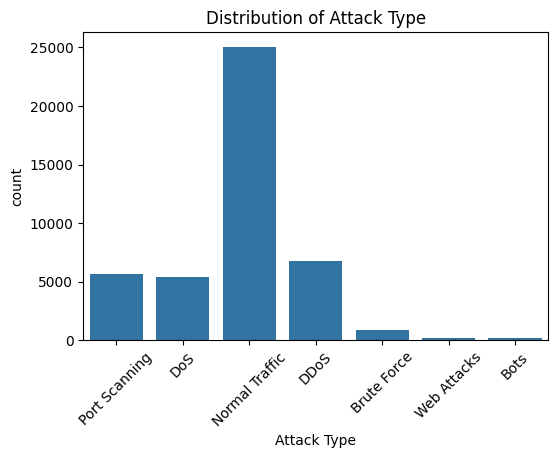

In [ ]:
# TARGET VARIABLE
plt.figure(figsize=(6,4))
sns.countplot(x='Attack Type', data=df)
plt.title("Distribution of Attack Type")
plt.xticks(rotation=45)
plt.show()

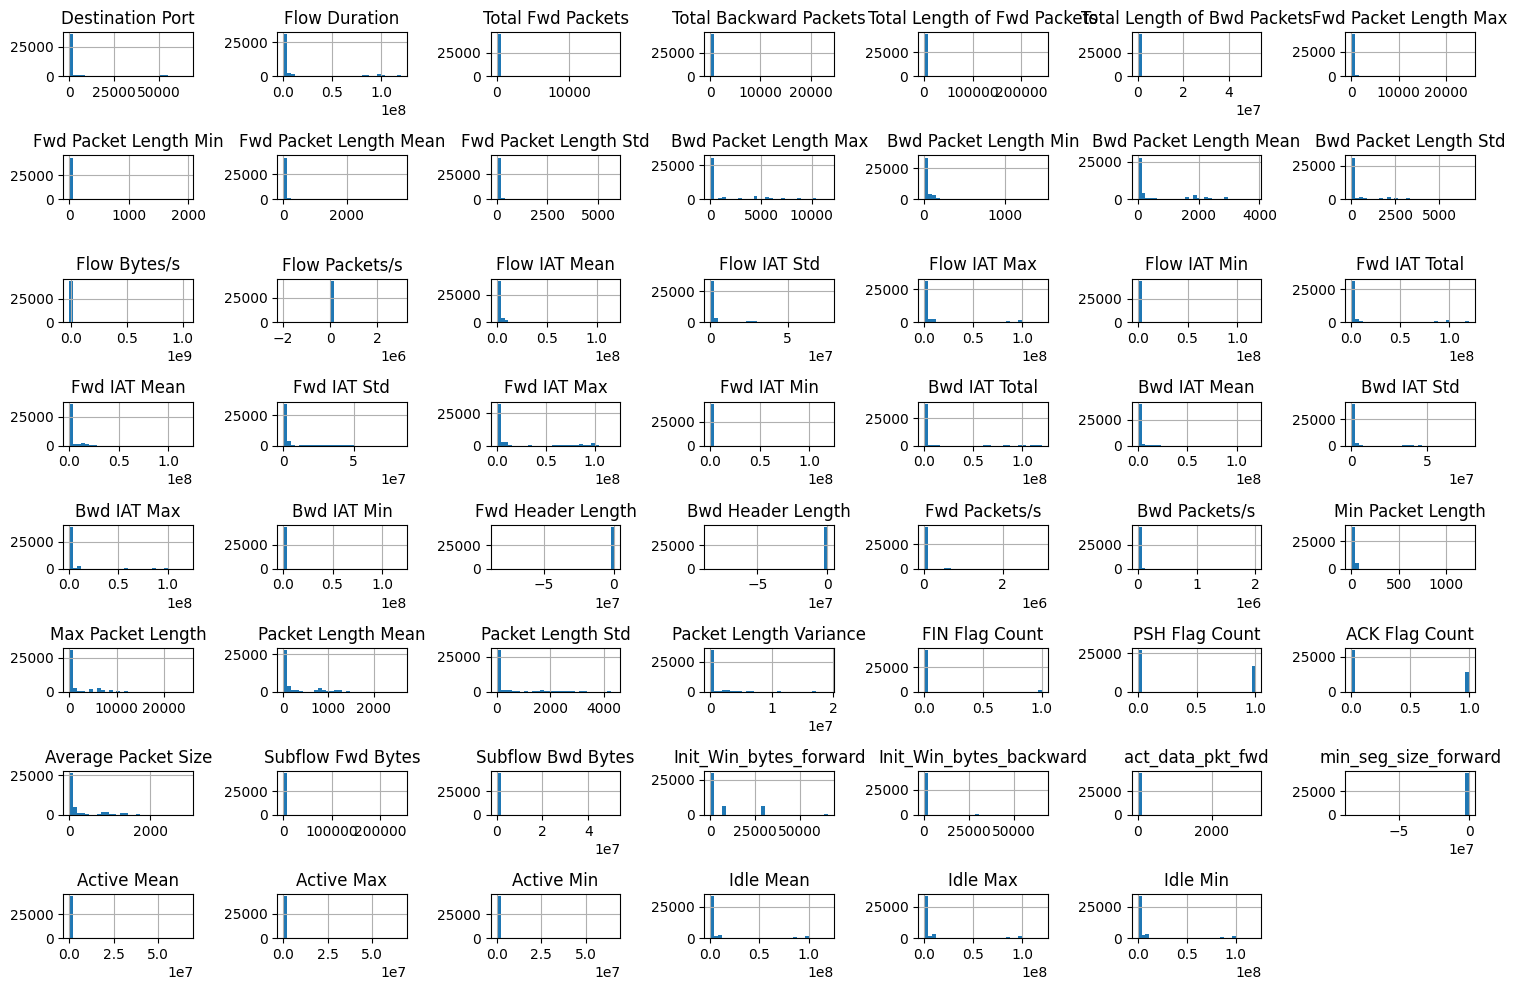

In [ ]:
# NUMERICAL FEATURE DISTRIBUTION
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(15,10), bins=30)
plt.tight_layout()
plt.show()

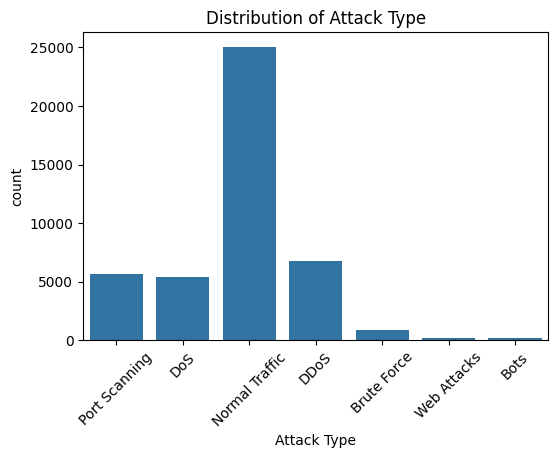

In [ ]:
# CATEGORICAL FEATURE DISTRIBUTION
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {col}")
    plt.show()

**# BIVARIATE ANALYSIS WITH TARGET**

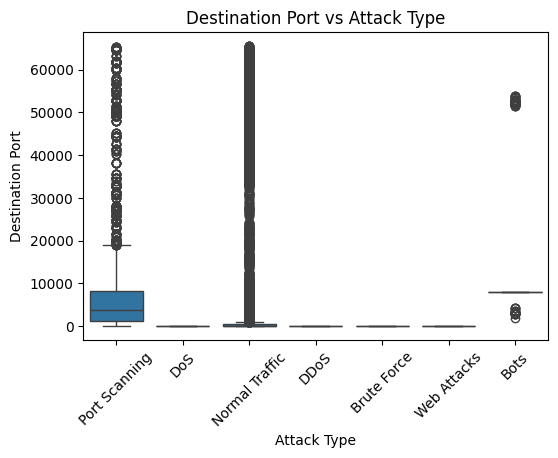

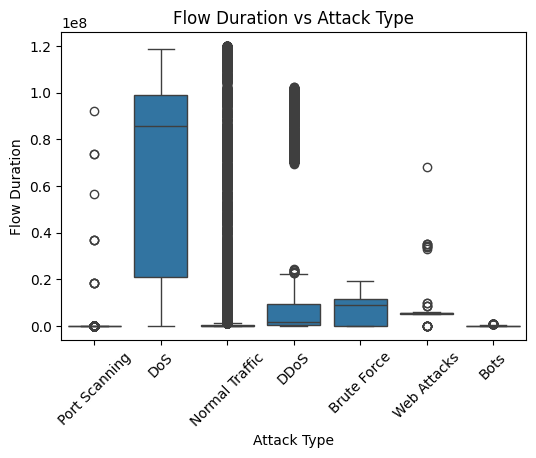

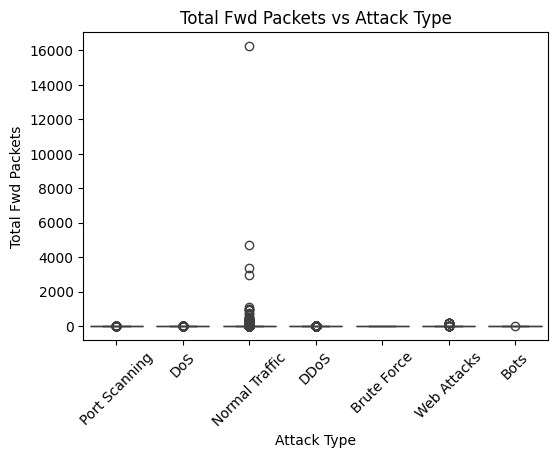

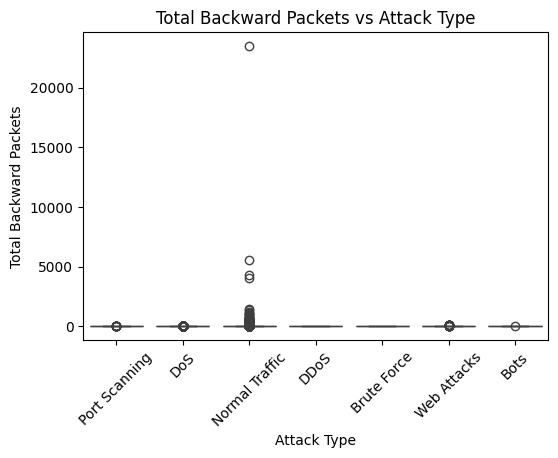

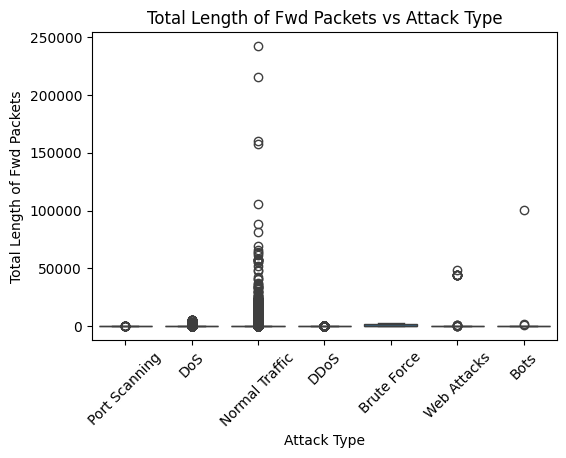

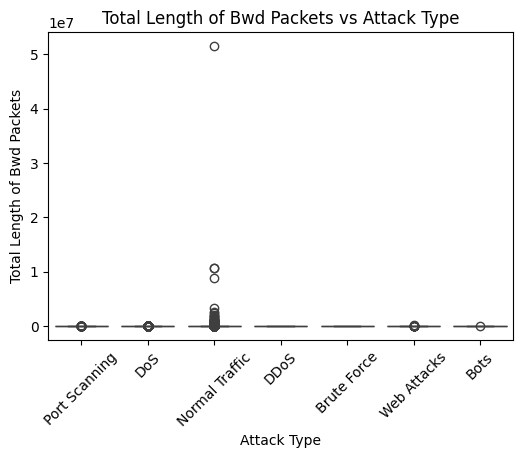

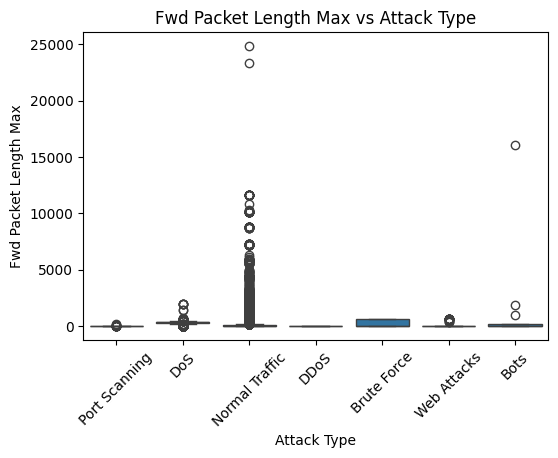

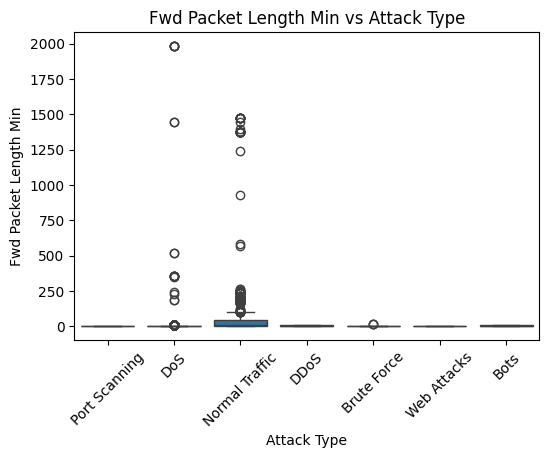

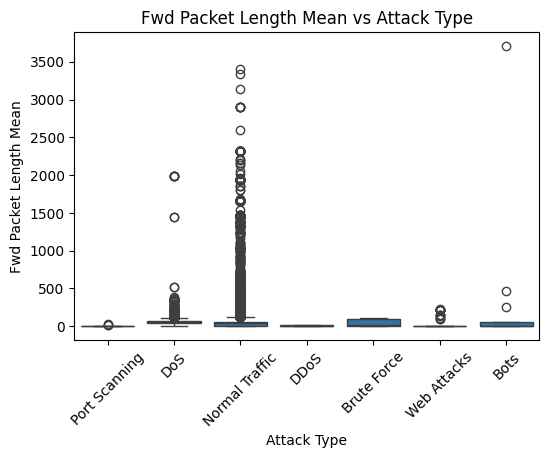

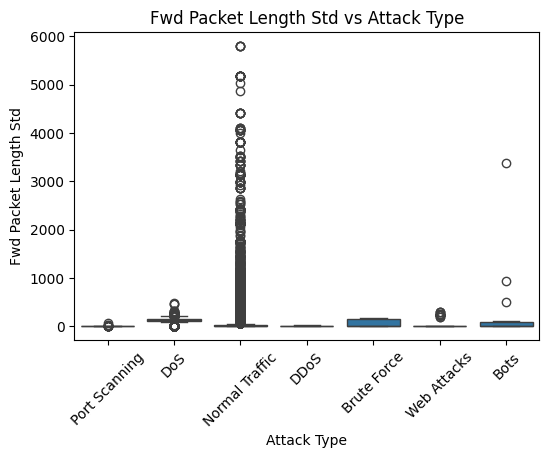

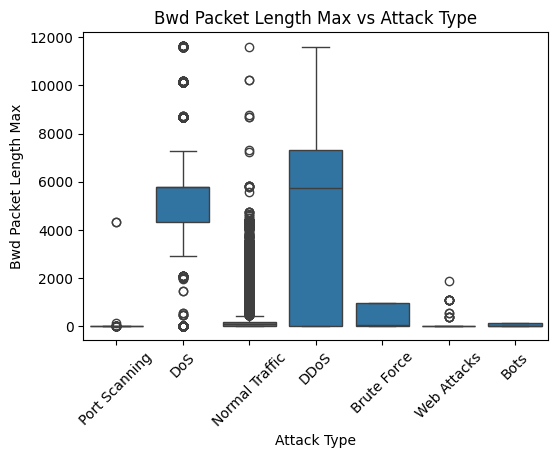

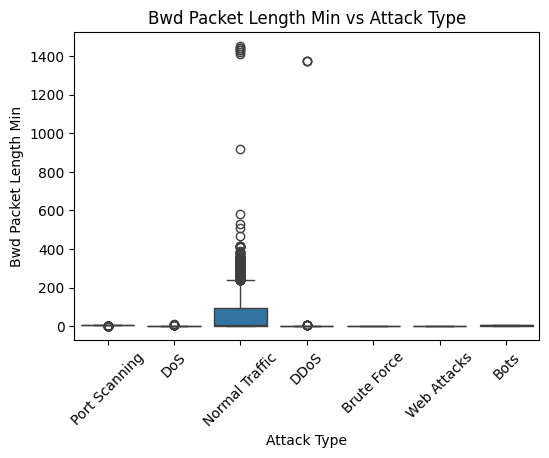

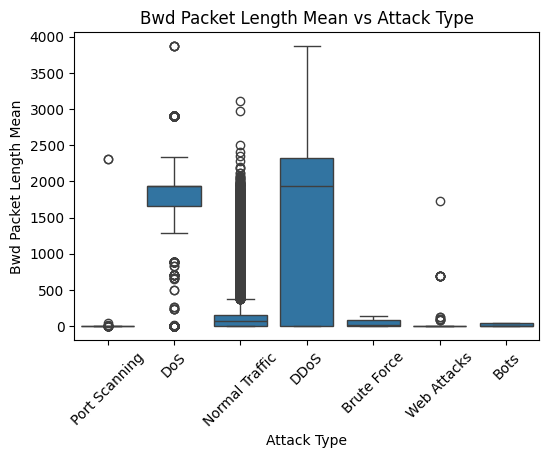

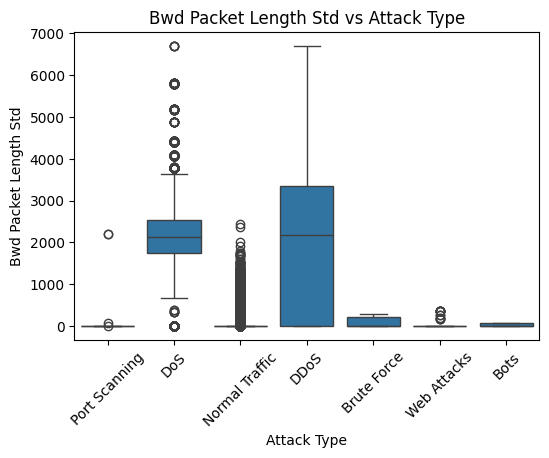

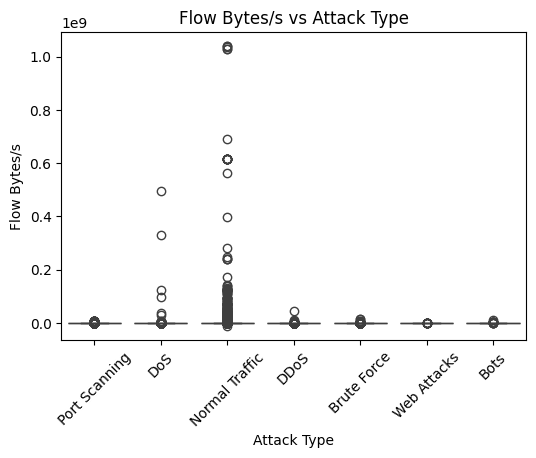

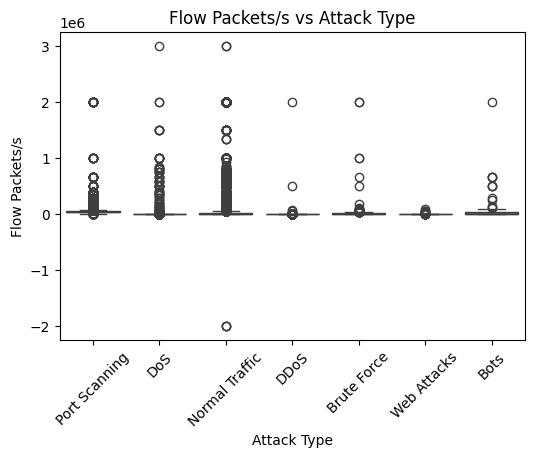

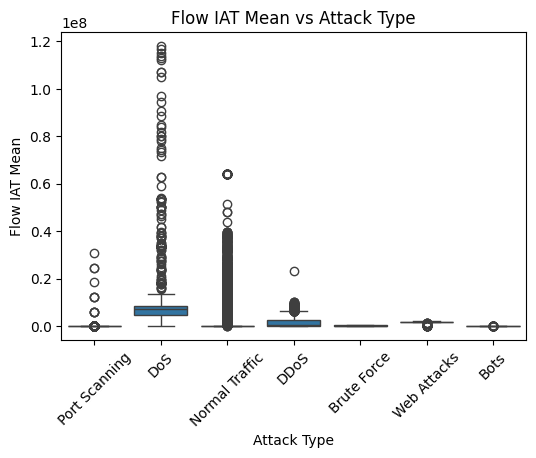

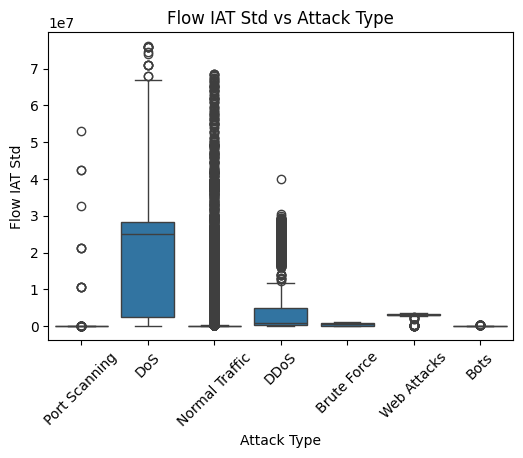

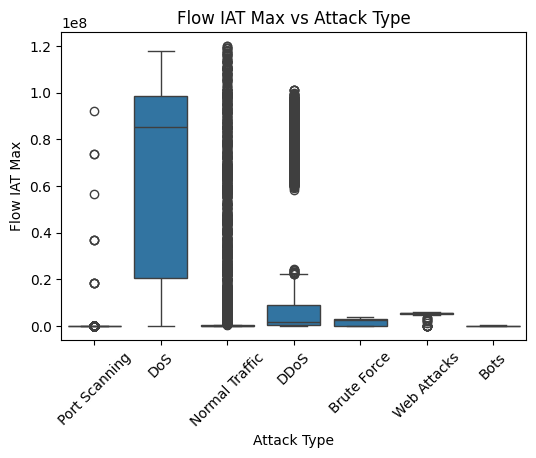

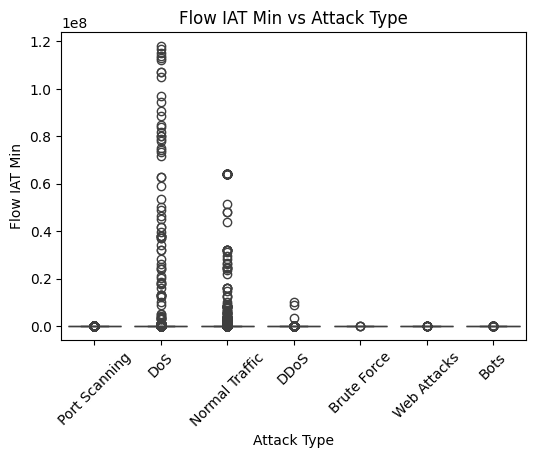

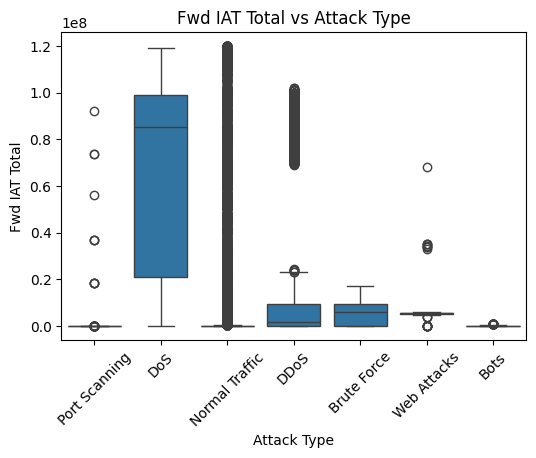

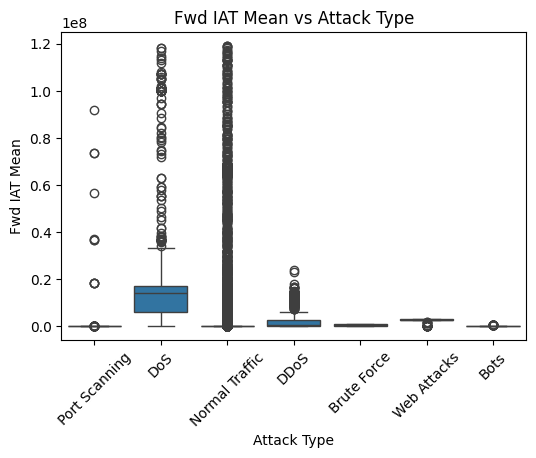

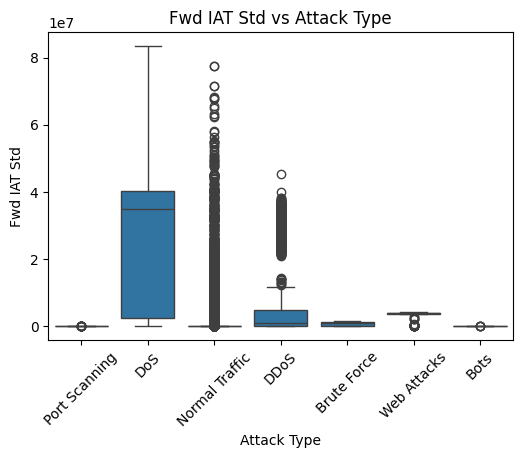

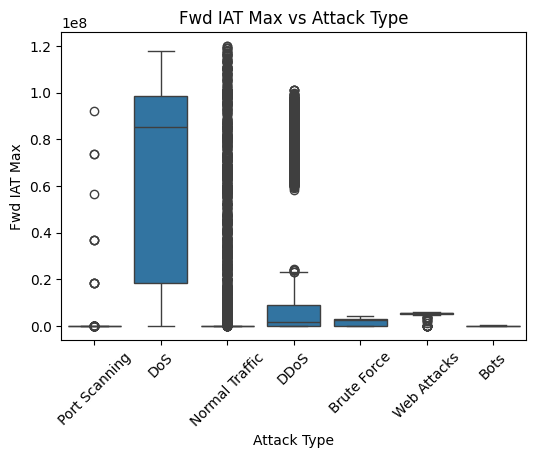

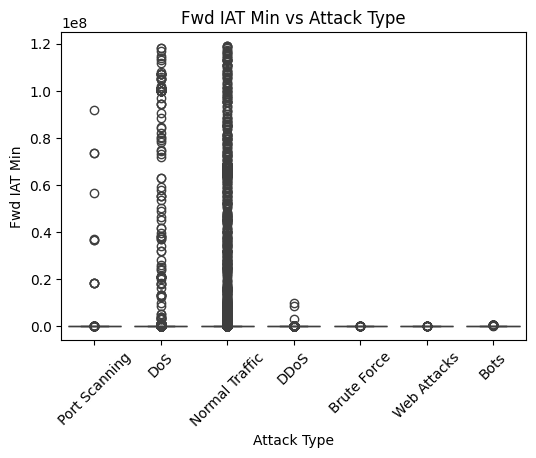

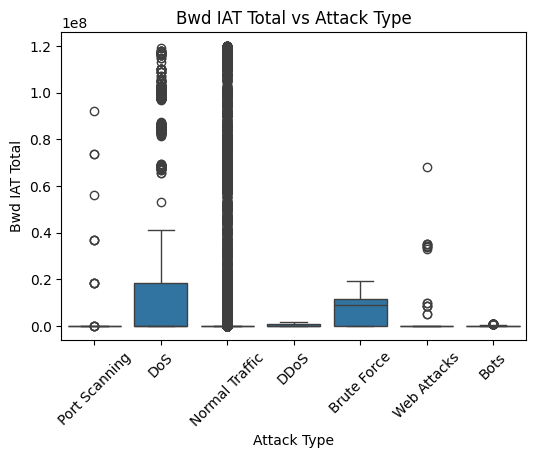

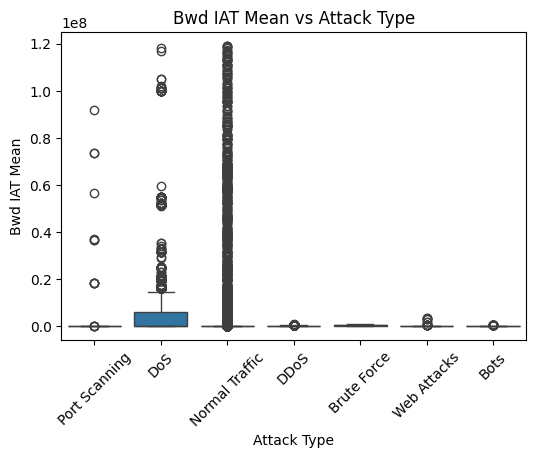

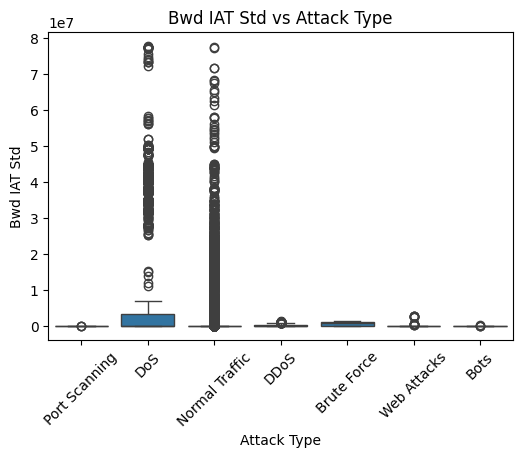

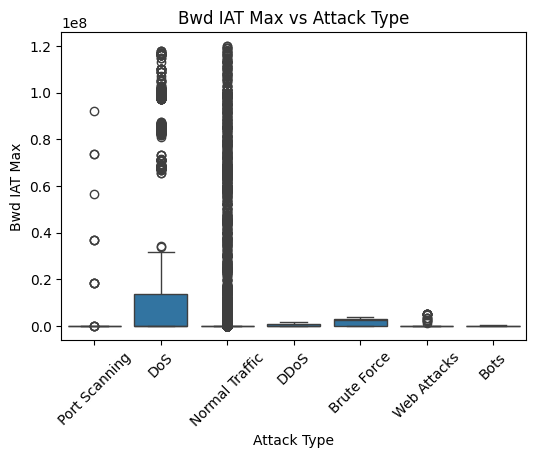

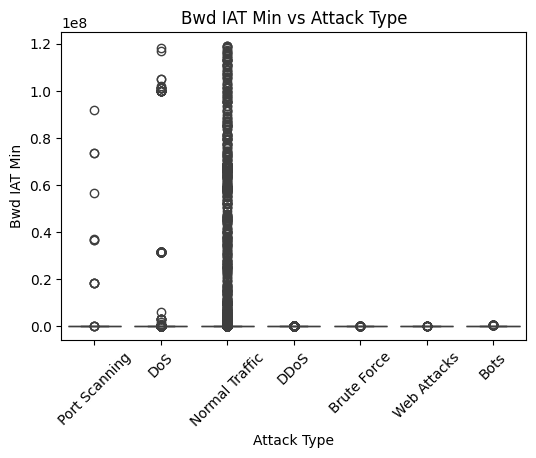

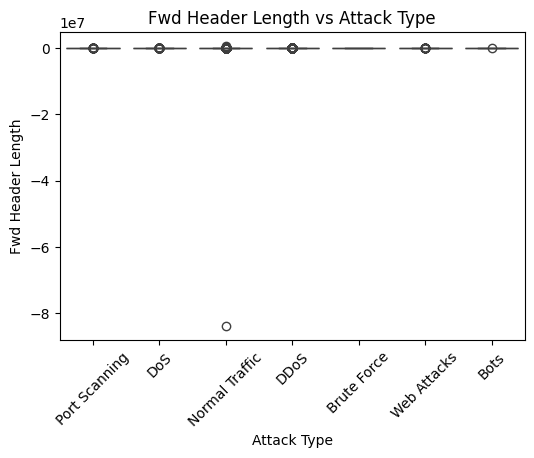

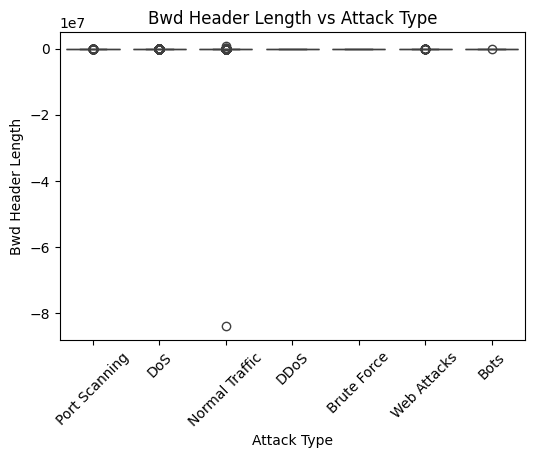

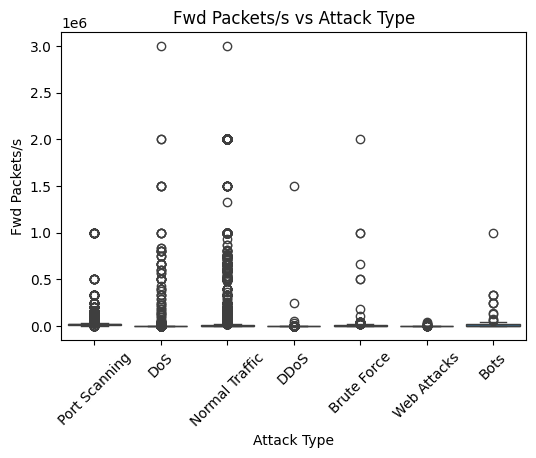

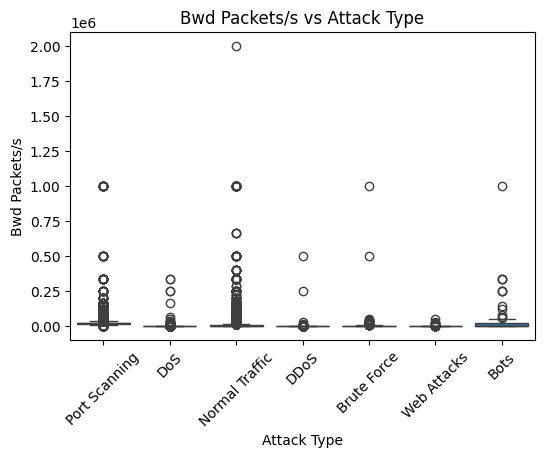

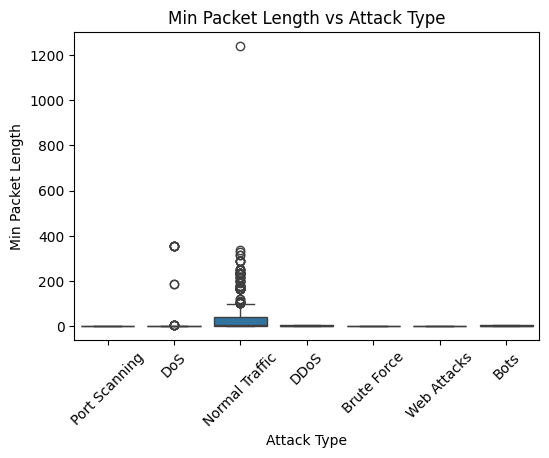

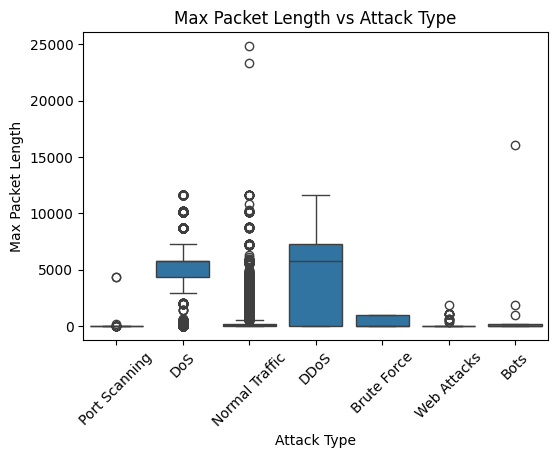

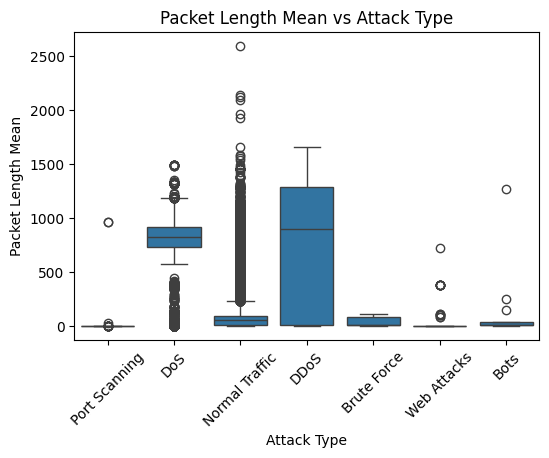

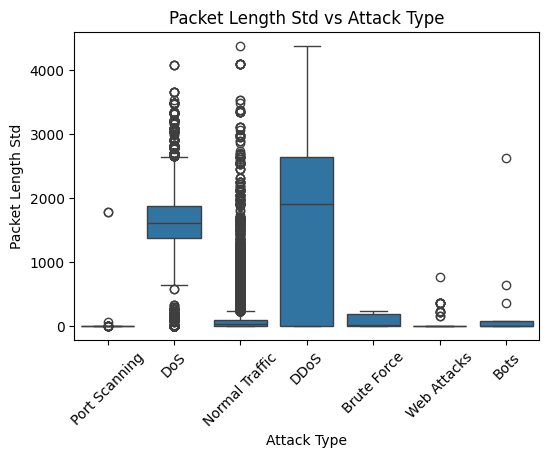

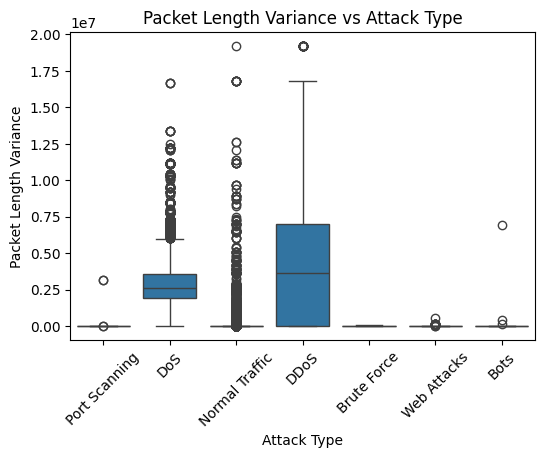

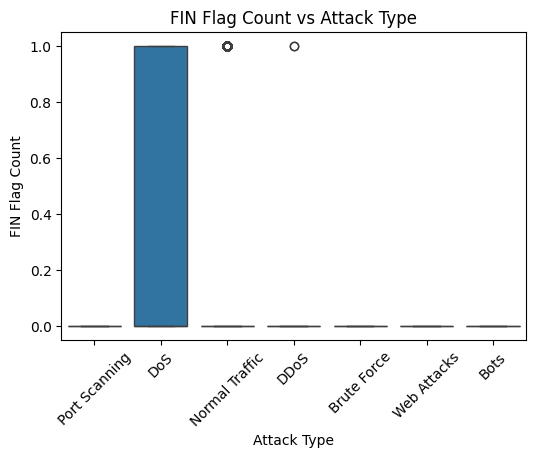

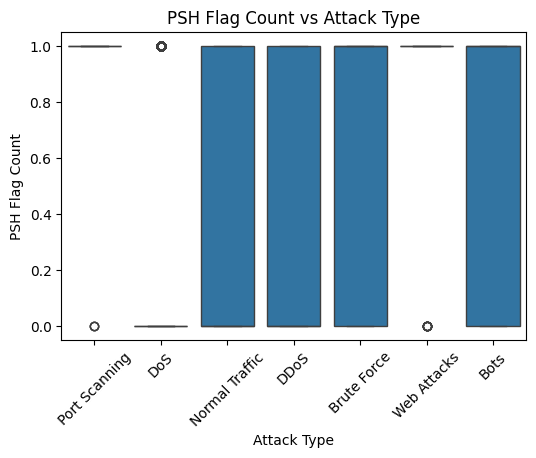

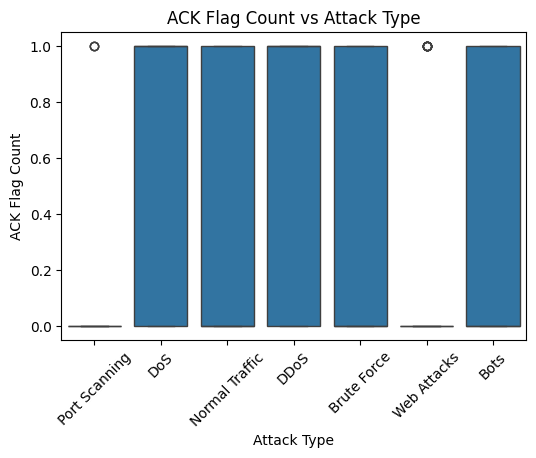

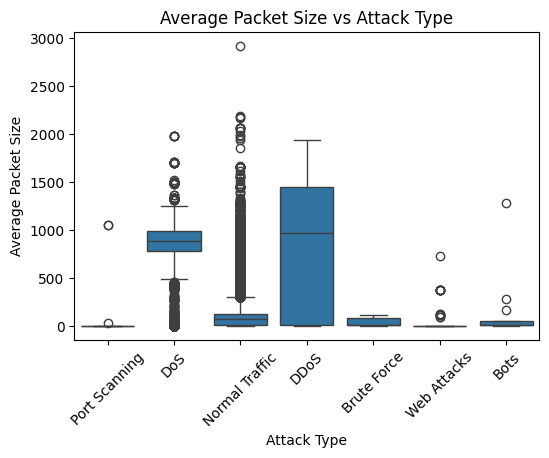

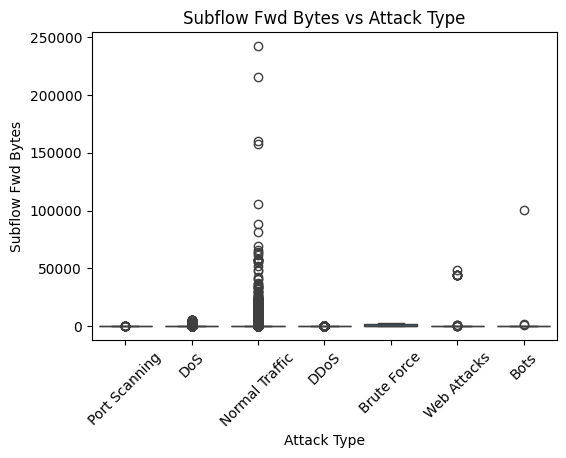

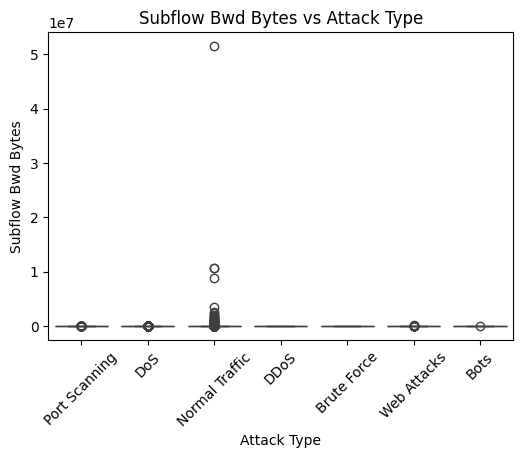

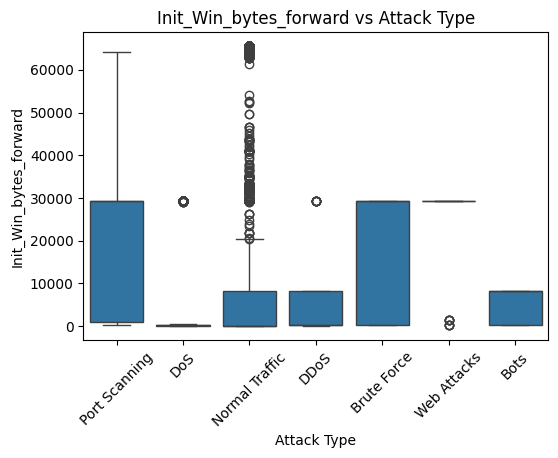

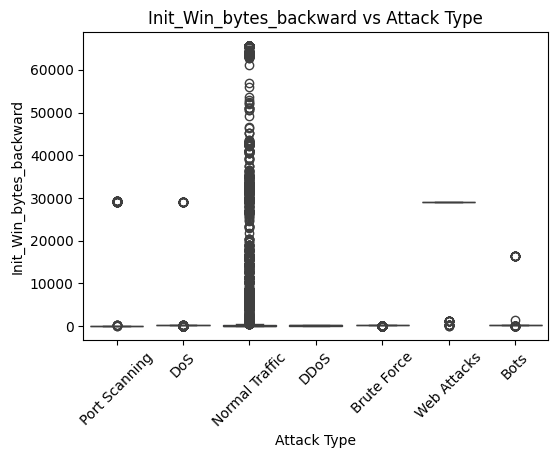

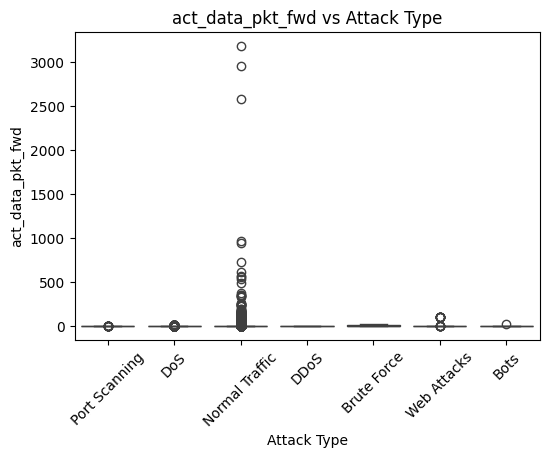

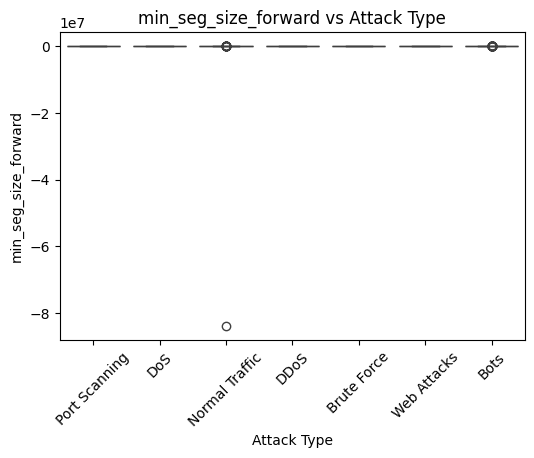

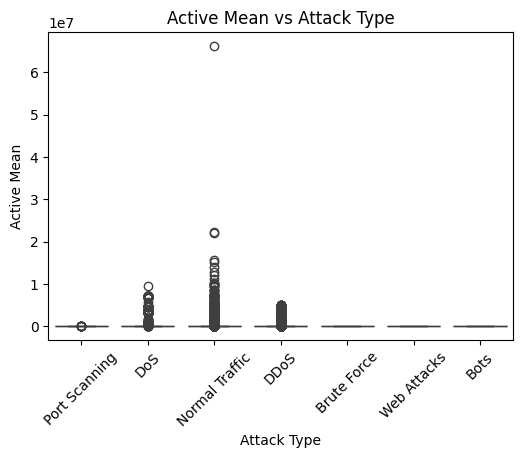

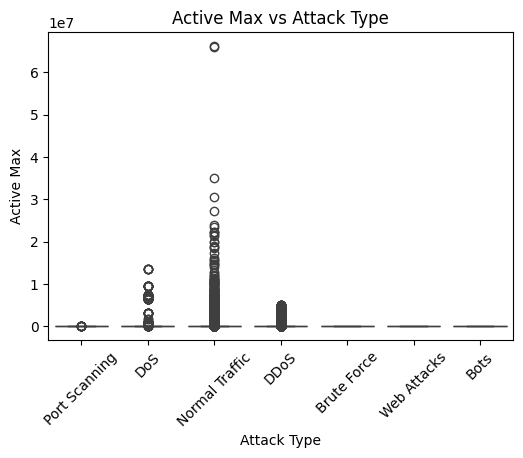

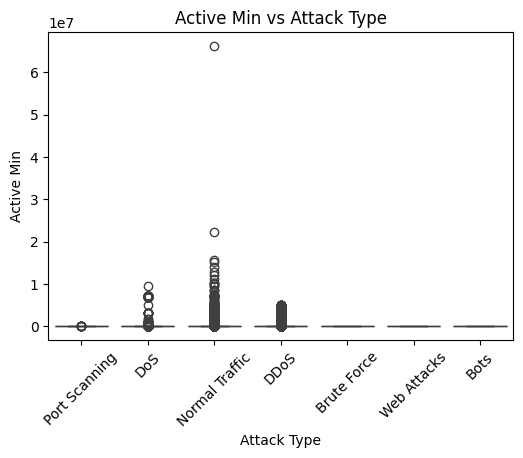

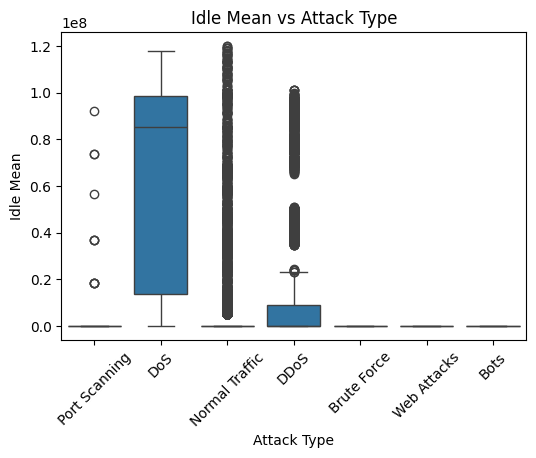

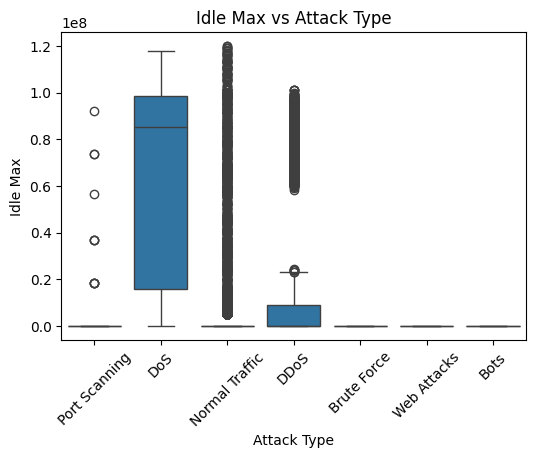

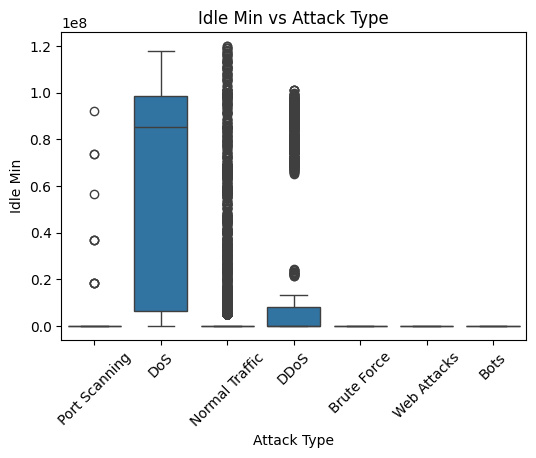

In [ ]:

# BOXPLOTS FOR NUMERICAL FEATURES
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Attack Type', y=col, data=df)
    plt.xticks(rotation=45)
    plt.title(f"{col} vs Attack Type")
    plt.show()

In [ ]:

# CATEGORICAL VS TARGET
for col in cat_cols:
    if col != 'Attack Type':
        plt.figure(figsize=(6,4))
        sns.countplot(x=col, hue='Attack Type', data=df)
        plt.xticks(rotation=45)
        plt.title(f"{col} vs Attack Type")
        plt.show()

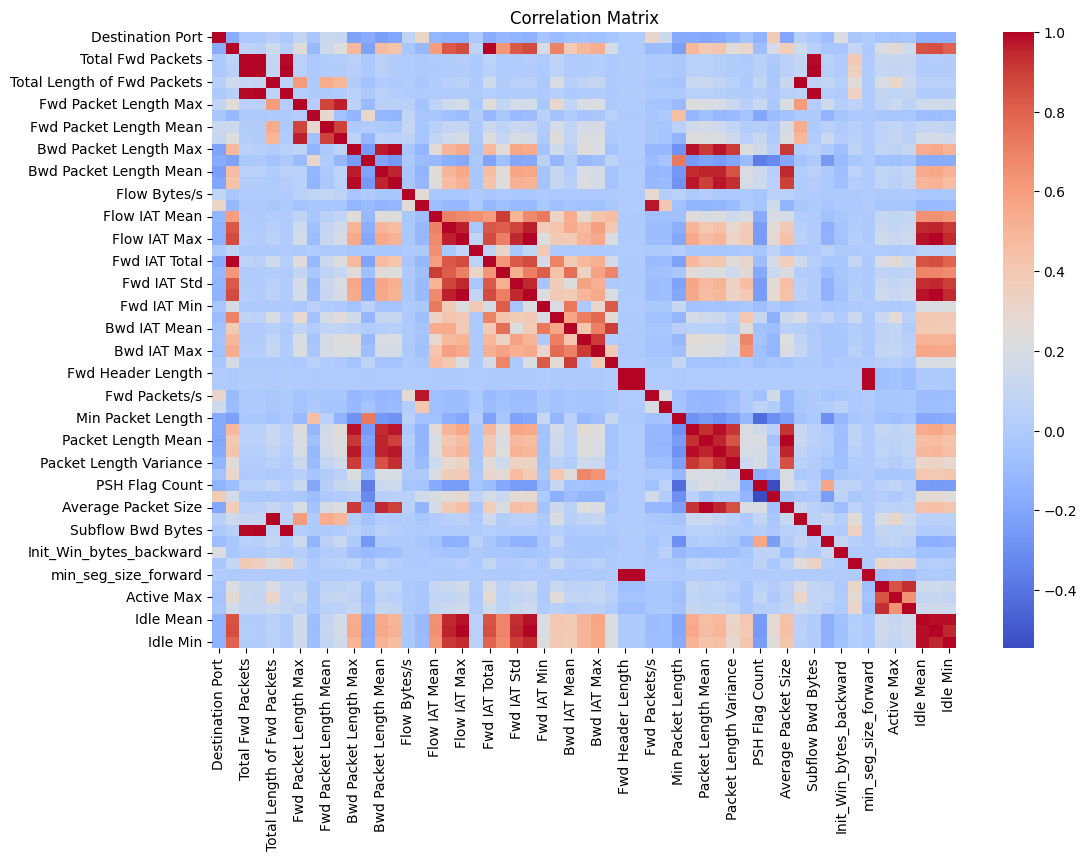

In [ ]:

# CORRELATION MATRIX
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [ ]:

# OUTLIER REMOVAL
for col in num_cols:
    lower = df[col].quantile(0.02)
    upper = df[col].quantile(0.95)
    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [ ]:

# CHECK SHAPE AFTER CLEANING
df.shape

(6314, 56)

**Define Features and Target**

In [ ]:
target_column = "Attack Type"

X = df.drop(columns=[target_column])
y = df[target_column]


**Encode Categorical Variables (ONLY ONCE)**

In [ ]:
X = pd.get_dummies(X, drop_first=True)


**Train-Test Split**

In [ ]:
print("Total NaN values:\n", df.isna().sum().sort_values(ascending=False).head(10))


Total NaN values:
 Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
Fwd Packet Length Max          0
Fwd Packet Length Min          0
Fwd Packet Length Mean         0
Fwd Packet Length Std          0
dtype: int64


In [ ]:
import numpy as np

df.replace([np.inf, -np.inf], np.nan, inplace=True)


In [ ]:
df.dropna(inplace=True)


In [ ]:
print("Remaining NaNs:", df.isna().sum().sum())


Remaining NaNs: 0


In [ ]:
X = df.drop('Attack Type', axis=1)
y = df['Attack Type']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


**Scale the Data**

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
X_train_scaled
X_test_scaled


array([[-0.58106881, -0.2717421 ,  1.86125355, ...,  0.        ,
         0.        ,  0.        ],
       [-0.58106881,  8.48029681,  1.86125355, ...,  0.        ,
         0.        ,  0.        ],
       [-0.58106881,  2.41395103,  1.86125355, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.50253931, -0.28225172, -0.52207866, ...,  0.        ,
         0.        ,  0.        ],
       [ 2.41030004, -0.28013213, -0.52207866, ...,  0.        ,
         0.        ,  0.        ],
       [-0.58106881, -0.26829777,  1.86125355, ...,  0.        ,
         0.        ,  0.        ]])

**Hyperparameter Tuning for Decision Tree**

In [ ]:
param_grid = {
    'max_depth': [8, 10, 15],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'criterion': ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=1,
    verbose=2
)

grid_dt.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_dt.best_params_)


Fitting 3 folds for each of 24 candidates, totalling 72 fits
[CV] END criterion=gini, max_depth=8, min_samples_leaf=2, min_samples_split=5; total time=   0.0s
[CV] END criterion=gini, max_depth=8, min_samples_leaf=2, min_samples_split=5; total time=   0.0s
[CV] END criterion=gini, max_depth=8, min_samples_leaf=2, min_samples_split=5; total time=   0.0s
[CV] END criterion=gini, max_depth=8, min_samples_leaf=2, min_samples_split=10; total time=   0.0s
[CV] END criterion=gini, max_depth=8, min_samples_leaf=2, min_samples_split=10; total time=   0.0s
[CV] END criterion=gini, max_depth=8, min_samples_leaf=2, min_samples_split=10; total time=   0.0s
[CV] END criterion=gini, max_depth=8, min_samples_leaf=4, min_samples_split=5; total time=   0.0s
[CV] END criterion=gini, max_depth=8, min_samples_leaf=4, min_samples_split=5; total time=   0.0s
[CV] END criterion=gini, max_depth=8, min_samples_leaf=4, min_samples_split=5; total time=   0.0s


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=3.
  warnings.warn(


[CV] END criterion=gini, max_depth=8, min_samples_leaf=4, min_samples_split=10; total time=   0.0s
[CV] END criterion=gini, max_depth=8, min_samples_leaf=4, min_samples_split=10; total time=   0.0s
[CV] END criterion=gini, max_depth=8, min_samples_leaf=4, min_samples_split=10; total time=   0.0s
[CV] END criterion=gini, max_depth=10, min_samples_leaf=2, min_samples_split=5; total time=   0.0s
[CV] END criterion=gini, max_depth=10, min_samples_leaf=2, min_samples_split=5; total time=   0.0s
[CV] END criterion=gini, max_depth=10, min_samples_leaf=2, min_samples_split=5; total time=   0.0s
[CV] END criterion=gini, max_depth=10, min_samples_leaf=2, min_samples_split=10; total time=   0.0s
[CV] END criterion=gini, max_depth=10, min_samples_leaf=2, min_samples_split=10; total time=   0.0s
[CV] END criterion=gini, max_depth=10, min_samples_leaf=2, min_samples_split=10; total time=   0.0s
[CV] END criterion=gini, max_depth=10, min_samples_leaf=4, min_samples_split=5; total time=   0.0s
[CV] EN

**Train Final Decision Tree Using Best Parameters**

In [ ]:
best_dt = grid_dt.best_estimator_

best_dt.fit(X_train_scaled, y_train)


DecisionTreeClassifier(class_weight='balanced', criterion='entropy',
                       max_depth=8, min_samples_leaf=2, min_samples_split=5,
                       random_state=42)

**Predict**

In [ ]:
y_dt_pred = best_dt.predict(X_test_scaled)


**Evaluate Model**

In [ ]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_dt_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_dt_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_dt_pred))


Decision Tree Accuracy: 0.9920844327176781

Classification Report:

                precision    recall  f1-score   support

          Bots       0.40      0.80      0.53         5
   Brute Force       1.00      1.00      1.00        23
           DoS       0.56      0.83      0.67         6
Normal Traffic       0.99      0.99      0.99       677
 Port Scanning       1.00      1.00      1.00      1183
   Web Attacks       1.00      1.00      1.00         1

      accuracy                           0.99      1895
     macro avg       0.82      0.94      0.86      1895
  weighted avg       0.99      0.99      0.99      1895


Confusion Matrix:

[[   4    0    0    1    0    0]
 [   0   23    0    0    0    0]
 [   0    0    5    1    0    0]
 [   6    0    4  667    0    0]
 [   0    0    0    3 1180    0]
 [   0    0    0    0    0    1]]


**Feature Importance**

In [ ]:
feature_importance = best_dt.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importance
}).sort_values(by='Importance', ascending=False)

print(importance_df)


                        Feature    Importance
0              Destination Port  5.100576e-01
37            Packet Length Std  2.114868e-01
46      Init_Win_bytes_backward  9.108799e-02
33                Bwd Packets/s  7.201193e-02
14                 Flow Bytes/s  3.909042e-02
19                 Flow IAT Min  1.869085e-02
45       Init_Win_bytes_forward  1.767739e-02
48         min_seg_size_forward  1.561234e-02
40               PSH Flag Count  1.226072e-02
18                 Flow IAT Max  1.131358e-02
34            Min Packet Length  3.334527e-04
15               Flow Packets/s  2.728710e-04
32                Fwd Packets/s  1.040566e-04
24                  Fwd IAT Min  2.497745e-16
6         Fwd Packet Length Max  1.805698e-16
3        Total Backward Packets  5.355967e-18
5   Total Length of Bwd Packets  0.000000e+00
1                 Flow Duration  0.000000e+00
4   Total Length of Fwd Packets  0.000000e+00
10        Bwd Packet Length Max  0.000000e+00
7         Fwd Packet Length Min  0

**Visualize Decision Tree**

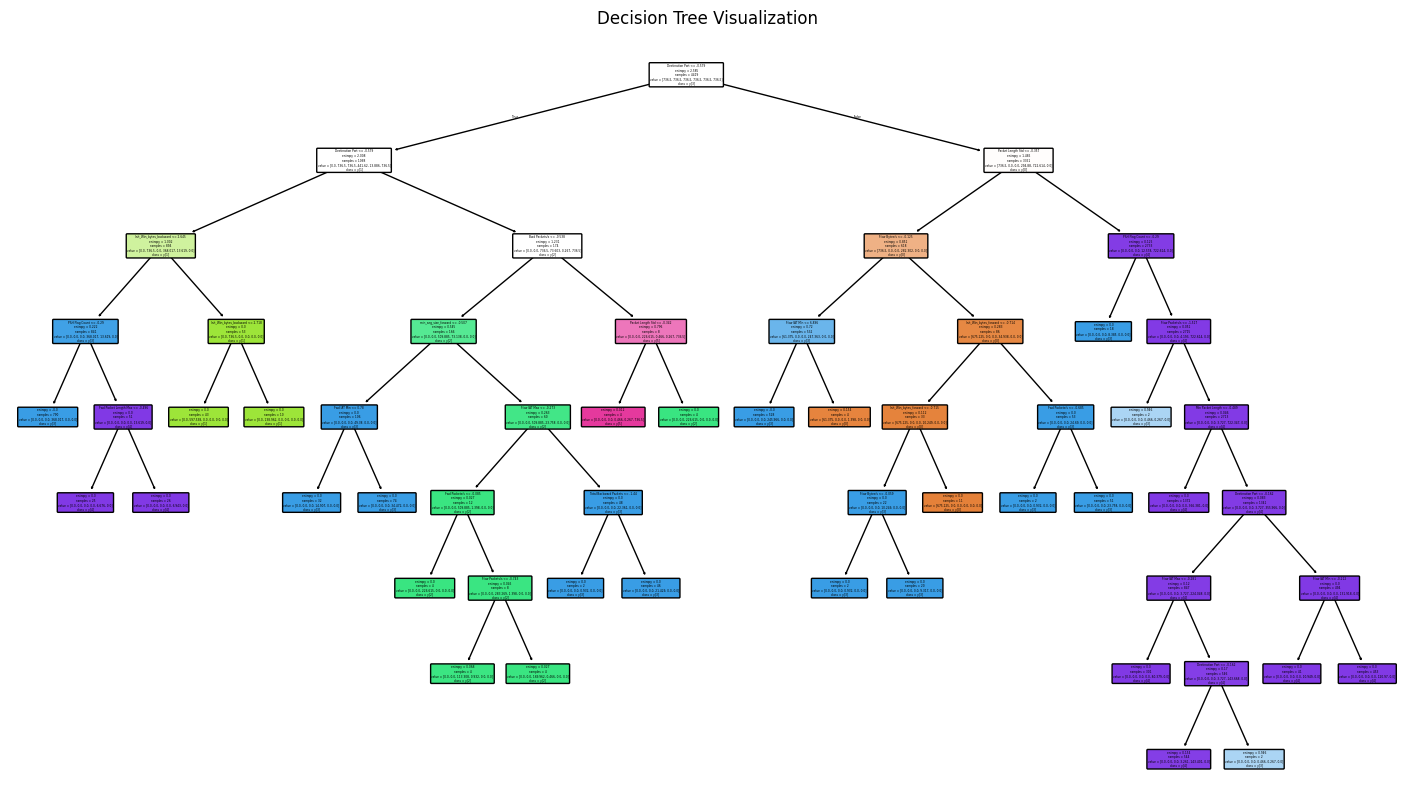

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))
plot_tree(
    best_dt,
    feature_names=X.columns,
    class_names=True,
    filled=True,
    rounded=True
)
plt.title("Decision Tree Visualization")
plt.show()

In [ ]:
import numpy as np

# Remove rows with NaN values from both x and y before splitting
# This ensures that the target variable 'y' does not contain any NaN values
# and that 'x' and 'y' remain aligned after removal.
valid_indices = y.dropna().index
x_cleaned = x.loc[valid_indices]
y_cleaned = y.loc[valid_indices]

# Identify classes with only one sample
class_counts = y_cleaned.value_counts()
single_instance_classes = class_counts[class_counts == 1].index

# Filter out samples belonging to single-instance classes
mask = ~y_cleaned.isin(single_instance_classes)
x_cleaned = x_cleaned[mask]
y_cleaned = y_cleaned[mask]

x_train, x_test, y_train, y_test = train_test_split(x_cleaned, y_cleaned, test_size=0.3, random_state=42, stratify=y_cleaned)

In [ ]:
# Initialize RobustScaler

scaler = RobustScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)

In [ ]:
rf_model = RandomForestClassifier(random_state=42, n_jobs=1)

In [ ]:
# Custom mapping for the attack types
label_mapping = {
    'Normal Traffic': 0,
    'DoS': 1,
    'DDoS': 2,
    'Port Scanning': 3,
    'Brute Force': 4,
    'Web Attacks': 5,
    'Bots': 6
}
y_train = y_train.map(label_mapping)
y_test = y_test.map(label_mapping)

In [ ]:

x_cleaned.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,Idle Mean,Idle Max,Idle Min
0,88,60,1,1,0,6,0,0,0.0,0.000000,...,29200,0,0,40,0.0,0,0,0.0,0,0
1,80,5,2,0,0,0,0,0,0.0,0.000000,...,251,-1,0,32,0.0,0,0,0.0,0,0
2,443,87142,4,2,24,0,6,6,6.0,0.000000,...,0,114,3,20,0.0,0,0,0.0,0,0
3,80,88657310,8,4,56,11601,20,0,7.0,5.656854,...,256,229,6,20,791024.0,791024,791024,87200000.0,87200000,87200000
4,10215,46,1,1,0,6,0,0,0.0,0.000000,...,29200,0,0,40,0.0,0,0,0.0,0,0


In [ ]:
y_train.unique()

array([0, 1, 3, 2, 5, 4, 6])

In [ ]:
y_train.head()

,Attack Type
402247,0
390040,0
462788,0
407334,1
222223,0


In [ ]:
num_classes = len(label_mapping)


In [ ]:

rf_model=RandomForestClassifier(
    n_estimators=100,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=6,
    random_state=42,
    n_jobs=1
)
rf_model.fit(x_train_scaled, y_train)
y_rf_pred = rf_model.predict(x_test_scaled)



In [ ]:
# Reverse mapping: 0 -> 'Normal Traffic'...
inv_label_mapping = {v: k for k, v in label_mapping.items()}
target_names = [inv_label_mapping[i] for i in range(num_classes)]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                precision    recall  f1-score   support

Normal Traffic       0.97      1.00      0.98     86885
           DoS       1.00      0.92      0.96     18626
          DDoS       1.00      1.00      1.00     23998
 Port Scanning       1.00      0.99      0.99     15327
   Brute Force       1.00      0.97      0.98      2745
   Web Attacks       0.00      0.00      0.00       643
          Bots       0.00      0.00      0.00       584

      accuracy                           0.98    148808
     macro avg       0.71      0.70      0.70    148808
  weighted avg       0.97      0.98      0.98    148808



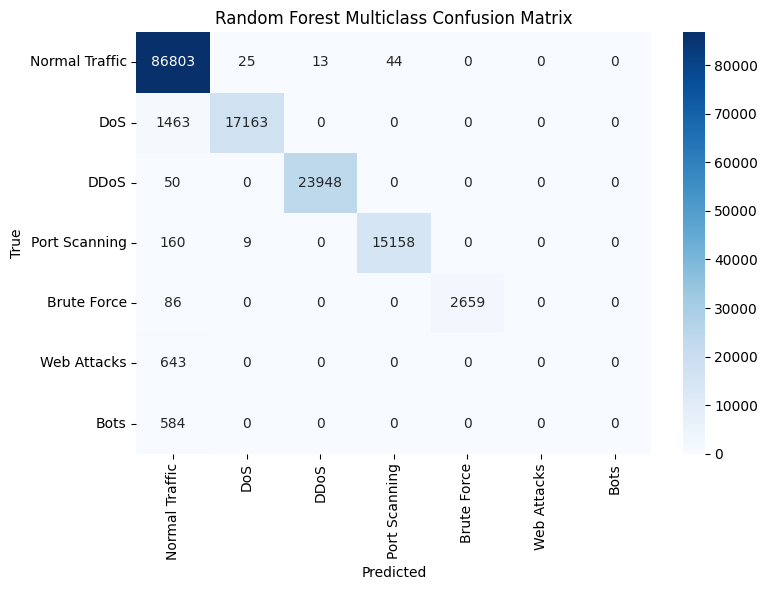

Random Forest Test Accuracy: 0.9793223482608462
Random Forest Train Accuracy: 0.979445130854768
Random Forest Test Error Rate: 0.0207
Random Forest Train Error Rate: 0.0206
Random Forest Mean Absolute Error: 0.0625
Random Forest Mean Absolute Error (Train): 0.0628


In [ ]:
# Get the unique numerical labels present in y_test
actual_labels_in_test = np.unique(y_test)

# Create target_names that correspond only to the actual_labels_in_test
# and sort them to ensure consistent ordering for plotting
actual_target_names = [inv_label_mapping[label] for label in sorted(actual_labels_in_test)]

print(classification_report(y_test, y_rf_pred, labels=actual_labels_in_test, target_names=actual_target_names))

cm_rf = confusion_matrix(y_test, y_rf_pred, labels=actual_labels_in_test)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=actual_target_names,
    yticklabels=actual_target_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Random Forest Multiclass Confusion Matrix")
plt.tight_layout()
plt.show()
# Test Accuracy
test_acc_rf = accuracy_score(y_test, y_rf_pred)
print("Random Forest Test Accuracy:", test_acc_rf)

# Train Accuracy
y_rf_train_pred = rf_model.predict(x_train_scaled)
train_acc_rf = accuracy_score(y_train, y_rf_train_pred)
print("Random Forest Train Accuracy:", train_acc_rf)

error_rate_rf = 1 - accuracy_score(y_test, y_rf_pred)
print(f"Random Forest Test Error Rate: {error_rate_rf:.4f}")

error_rate_train_rf = 1 - accuracy_score(y_train, y_rf_train_pred)
print(f"Random Forest Train Error Rate: {error_rate_train_rf:.4f}")

mae_rf = mean_absolute_error(y_test, y_rf_pred)
print(f"Random Forest Mean Absolute Error: {mae_rf:.4f}")

mae_train_rf = mean_absolute_error(y_train, y_rf_train_pred)
print(f"Random Forest Mean Absolute Error (Train): {mae_train_rf:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                precision    recall  f1-score   support

Normal Traffic       0.97      1.00      0.98     86885
           DoS       1.00      0.92      0.96     18626
          DDoS       1.00      1.00      1.00     23998
 Port Scanning       1.00      0.99      0.99     15327
   Brute Force       1.00      0.97      0.98      2745
   Web Attacks       0.00      0.00      0.00       643
          Bots       0.00      0.00      0.00       584

      accuracy                           0.98    148808
     macro avg       0.71      0.70      0.70    148808
  weighted avg       0.97      0.98      0.98    148808



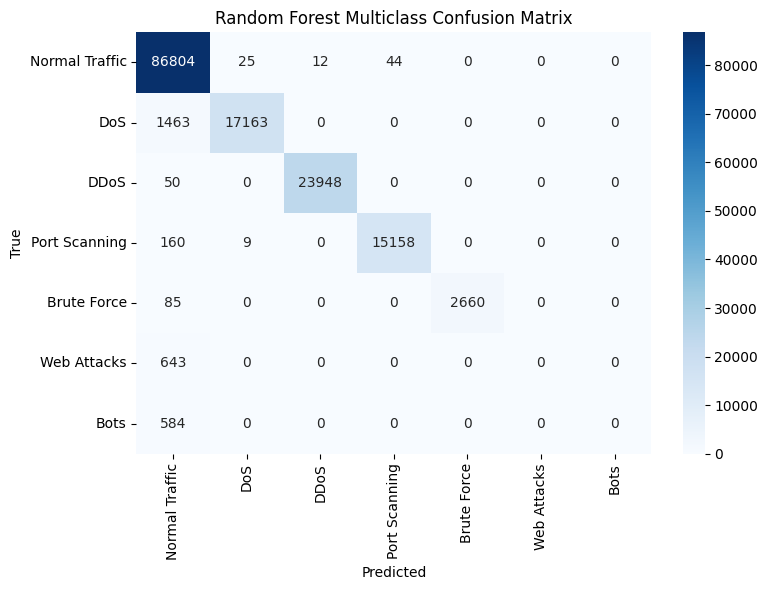

Random Forest Test Accuracy: 0.9793357883984732
Random Forest Train Accuracy: 0.9794480108980839
Random Forest Test Error Rate: 0.0207
Random Forest Train Error Rate: 0.0206
Random Forest Mean Absolute Error: 0.0625
Random Forest Mean Absolute Error (Train): 0.0628


In [ ]:
# Split data into training and testing sets using the cleaned data (x_cleaned, y_cleaned)
X_train, X_test, y_train, y_test = train_test_split(x_cleaned, y_cleaned, test_size=0.3, random_state=42, stratify=y_cleaned)

# Apply the label mapping to the target variables to convert them to numerical format
y_train = y_train.map(label_mapping)
y_test = y_test.map(label_mapping)

# Scale features
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
x_test_scaled = scaler.transform(X_test)

rf_model=RandomForestClassifier(
    n_estimators=100,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    max_depth=6,
    random_state=42,
    n_jobs=1
)
rf_model.fit(x_train_scaled, y_train)
y_rf_pred = rf_model.predict(x_test_scaled)

# Reverse mapping: 0 -> 'Normal Traffic' for display purposes
inv_label_mapping = {v: k for k, v in label_mapping.items()}

# Get the unique numerical labels present in y_test after mapping
actual_labels_in_test = np.unique(y_test)

# Create target_names that correspond only to the actual_labels_in_test
# and sort them to ensure consistent ordering for plotting
actual_target_names = [inv_label_mapping[label] for label in sorted(actual_labels_in_test)]

print(classification_report(y_test, y_rf_pred, labels=actual_labels_in_test, target_names=actual_target_names))
cm_rf = confusion_matrix(y_test, y_rf_pred, labels=actual_labels_in_test)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=actual_target_names,
    yticklabels=actual_target_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Random Forest Multiclass Confusion Matrix")
plt.tight_layout()
plt.show()
# Test Accuracy
test_acc_rf = accuracy_score(y_test, y_rf_pred)
print("Random Forest Test Accuracy:", test_acc_rf)

# Train Accuracy
y_rf_train_pred = rf_model.predict(x_train_scaled)
train_acc_rf = accuracy_score(y_train, y_rf_train_pred)
print("Random Forest Train Accuracy:", train_acc_rf)

error_rate_rf = 1 - accuracy_score(y_test, y_rf_pred)
print(f"Random Forest Test Error Rate: {error_rate_rf:.4f}")

error_rate_train_rf = 1 - accuracy_score(y_train, y_rf_train_pred)
print(f"Random Forest Train Error Rate: {error_rate_train_rf:.4f}")

mae_rf = mean_absolute_error(y_test, y_rf_pred)
print(f"Random Forest Mean Absolute Error: {mae_rf:.4f}")

mae_train_rf = mean_absolute_error(y_train, y_rf_train_pred)
print(f"Random Forest Mean Absolute Error (Train): {mae_train_rf:.4f}")

In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [ ]:

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class Weights:", class_weight_dict)

Class Weights: {np.int64(0): np.float64(0.2446699513220832), np.int64(1): np.float64(1.1413614802786205), np.int64(2): np.float64(0.8858525658361355), np.int64(3): np.float64(1.386976164511606), np.int64(4): np.float64(7.744329207092673), np.int64(5): np.float64(33.068285714285715), np.int64(6): np.float64(36.36541684122329)}


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder to map the actual unique labels in y_train to a contiguous range
le_xgb = LabelEncoder()
y_train_encoded = le_xgb.fit_transform(y_train)

# Transform y_test using the same encoder. It's assumed y_test will not contain labels not seen in y_train
y_test_encoded = le_xgb.transform(y_test)

# Recalculate class_weights based on the encoded y_train labels
classes_encoded = np.unique(y_train_encoded)
class_weights_encoded = compute_class_weight(
    class_weight='balanced',
    classes=classes_encoded,
    y=y_train_encoded
)
class_weight_dict_encoded = dict(zip(classes_encoded, class_weights_encoded))
sample_weights_encoded = np.array([class_weight_dict_encoded[label] for label in y_train_encoded])

In [ ]:
# Update num_class for XGBoost to match the number of unique classes in the encoded training data.
# le_xgb.classes_ contains the unique original labels, and its length is the number of classes.
num_classes_for_xgb_training = len(le_xgb.classes_)

xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=num_classes_for_xgb_training,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model.fit(
    X_train,
    y_train_encoded, # Use the encoded training labels
    sample_weight=sample_weights_encoded # Use the re-calculated sample weights
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=7, ...)

**Evaluate XGBoost Model**

XGBoost Classification Report:
                precision    recall  f1-score   support

Normal Traffic       1.00      1.00      1.00     86885
           DoS       1.00      1.00      1.00     18626
          DDoS       1.00      1.00      1.00     23998
 Port Scanning       1.00      1.00      1.00     15327
   Brute Force       1.00      1.00      1.00      2745
   Web Attacks       1.00      0.99      0.99       643
          Bots       0.93      1.00      0.96       584

      accuracy                           1.00    148808
     macro avg       0.99      1.00      0.99    148808
  weighted avg       1.00      1.00      1.00    148808



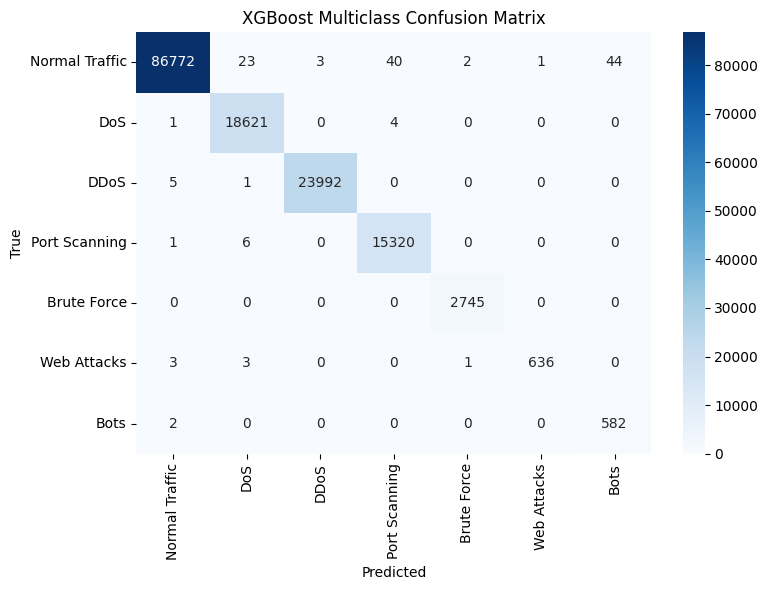

XGBoost Test Accuracy: 0.9991
XGBoost Train Accuracy: 0.9994
XGBoost Test Error Rate: 0.0009
XGBoost Train Error Rate: 0.0006
XGBoost Mean Absolute Error: 0.0034
XGBoost Mean Absolute Error (Train): 0.0025


In [ ]:
# Make predictions on the test set using the trained XGBoost model
y_xgb_pred_encoded = xgb_model.predict(X_test)

# Inverse transform the encoded predictions and actual test labels back to their original string representation
y_xgb_pred = le_xgb.inverse_transform(y_xgb_pred_encoded)
y_test_original = le_xgb.inverse_transform(y_test_encoded)

# Get the unique original labels present in y_test_original
actual_labels_in_test_original = np.unique(y_test_original)

# Create target_names that correspond only to the actual_labels_in_test_original
# Sort them to ensure consistent ordering for plotting
actual_target_names_xgb = [inv_label_mapping[label] for label in sorted(np.unique(y_test_original))]

print("XGBoost Classification Report:")
print(classification_report(y_test_original, y_xgb_pred, labels=actual_labels_in_test_original, target_names=actual_target_names_xgb))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test_original, y_xgb_pred, labels=actual_labels_in_test_original)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=actual_target_names_xgb,
    yticklabels=actual_target_names_xgb
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("XGBoost Multiclass Confusion Matrix")
plt.tight_layout()
plt.show()

# Test Accuracy
test_acc_xgb = accuracy_score(y_test_original, y_xgb_pred)
print(f"XGBoost Test Accuracy: {test_acc_xgb:.4f}")

# Train Accuracy (optional, but good for checking for overfitting)
y_xgb_train_pred_encoded = xgb_model.predict(X_train)
y_xgb_train_pred = le_xgb.inverse_transform(y_xgb_train_pred_encoded)
y_train_original = le_xgb.inverse_transform(y_train_encoded)
train_acc_xgb = accuracy_score(y_train_original, y_xgb_train_pred)
print(f"XGBoost Train Accuracy: {train_acc_xgb:.4f}")

error_rate_xgb = 1 - test_acc_xgb
print(f"XGBoost Test Error Rate: {error_rate_xgb:.4f}")

error_rate_train_xgb = 1 - train_acc_xgb
print(f"XGBoost Train Error Rate: {error_rate_train_xgb:.4f}")

mae_xgb = mean_absolute_error(y_test_original, y_xgb_pred)
print(f"XGBoost Mean Absolute Error: {mae_xgb:.4f}")

mae_train_xgb = mean_absolute_error(y_train_original, y_xgb_train_pred)
print(f"XGBoost Mean Absolute Error (Train): {mae_train_xgb:.4f}")

In [ ]:
y_xgb_pred = xgb_model.predict(X_test)

In [ ]:

print("XGBoost Accuracy:", accuracy_score(y_test, y_xgb_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_xgb_pred))

XGBoost Accuracy: 0.9990591903661094

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     86885
           1       1.00      1.00      1.00     18626
           2       1.00      1.00      1.00     23998
           3       1.00      1.00      1.00     15327
           4       1.00      1.00      1.00      2745
           5       1.00      0.99      0.99       643
           6       0.93      1.00      0.96       584

    accuracy                           1.00    148808
   macro avg       0.99      1.00      0.99    148808
weighted avg       1.00      1.00      1.00    148808



In [ ]:
# Re-predict y_dt_pred using the current scaled test set (x_test_scaled from NofYmSIP-bBZ)
# Note: This assumes best_dt can accept x_test_scaled and that the scaler used for x_test_scaled
# is compatible with how best_dt was trained. For precise comparison, the entire DT pipeline
# should ideally be re-run with the same data split and scaling as RF/XGBoost.
y_dt_pred_raw_strings = best_dt.predict(x_test_scaled)

# Map the string predictions to numerical labels using the label_mapping dictionary
y_dt_pred_numeric = np.array([label_mapping[label] for label in y_dt_pred_raw_strings])

print("Decision Tree Accuracy :", accuracy_score(y_test, y_dt_pred_numeric))
print("Random Forest Accuracy :", accuracy_score(y_test, y_rf_pred))
print("XGBoost Accuracy       :", accuracy_score(y_test, y_xgb_pred))

Decision Tree Accuracy : 0.47583463254663727
Random Forest Accuracy : 0.9793357883984732
XGBoost Accuracy       : 0.9990591903661094
